In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# This notebook uses DriftXpress; exact drift uses its separate loss/cache API in src.drift.
from src.driftXpress import *
from src.eval import *
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def decode(self, z):
        return self.decoder(z)


class LatentGenerator(nn.Module):
    def __init__(self, latent_dim=16, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def forward(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        return self.generator(h)


class f(nn.Module):
    # Frozen VAE plus a separately trained conditional generator.
    def __init__(self, vae_model, generator_model, num_classes=6):
        super().__init__()
        self.vae = vae_model
        self.generator_model = generator_model
        self.latent_dim = vae_model.latent_dim
        self.num_classes = num_classes

    def get_latent(self, x):
        return self.vae.get_latent(x)

    def decode(self, z):
        return self.vae.decode(z)

    def generate(self, noise, labels):
        z = self.generator_model(noise, labels)
        return z, self.vae.decode(z)


In [26]:
vae = VAE()
gen = LatentGenerator()
model = f(vae, gen)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 351088
Trainable parameters: 351088


In [27]:
model = VAE()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 343920
Trainable parameters: 343920


In [28]:
model = LatentGenerator()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 7168
Trainable parameters: 7168


In [4]:
def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    # Build fixed class-conditional attraction summaries once.
    model.eval()
    references = {digit: [] for digit in range(num_classes)}
    with torch.no_grad():
        for images, labels in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            _, _, z = model.get_latent(x)
            labels = labels.to(device, non_blocking=True)
            for digit in range(num_classes):
                mask = labels == digit
                if mask.any():
                    references[digit].append(z[mask].detach())

    cache = {}
    bank = []
    for digit in range(num_classes):
        if not references[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")
        support = torch.cat(references[digit], dim=0)
        bank.append(support)
        landmarks = select_landmarks(support, num_landmarks)
        W = build_nystrom_cache(landmarks, T)
        A, b = pre_compute_summaries(support, landmarks, W, T)
        cache[digit] = (landmarks, W, A, b)
    return cache, torch.cat(bank, dim=0)


def conditional_drift_loss(generated, labels, cache, T):
    total = generated.new_zeros(())
    field = torch.zeros_like(generated)
    batch_size = generated.shape[0]
    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, W, A, b = cache[digit]
        digit_loss, digit_field = drift_loss(
            generated[mask], landmarks, W, A, b, T
        )
        total = total + (mask.float().sum() / batch_size) * digit_loss
        field[mask] = digit_field
    return total, field

def training_loop(num_epochs, T, num_landmarks,
                  lambda_kl, lambda_drift, lambda_var, lambda_cov,
                  batch_size=1000, lr=1e-3):
    vae_model = VAE(784, LATENT_DIM).to(device)
    vae_optimizer = optim.AdamW(vae_model.parameters(), lr=lr)
    train_losses, recon_losses, kl_losses = [], [], []
    drift_losses, var_losses, covar_losses = [], [], []
    average_V, evolution = [], []

    print("VAE training started")
    for epoch in range(num_epochs + 1):
        vae_model.train()
        items = {k: 0.0 for k in ("total", "recon", "kl", "var", "covar")}
        for images, _ in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            mu, logvar, z = vae_model.get_latent(x)
            recon = vae_model.decode(z)
            L_recon, L_kl = recon_loss(recon, x), kl_loss(mu, logvar)
            L_var, L_cov = variance_loss(mu), covariance_loss(mu)
            loss = L_recon + lambda_kl * L_kl + lambda_var * L_var + lambda_cov * L_cov
            vae_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_model.parameters(), 5.0)
            vae_optimizer.step()
            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
        n = len(train_loader)
        for key in items:
            items[key] /= n
        train_losses.append(items["total"])
        recon_losses.append(items["recon"])
        kl_losses.append(items["kl"])
        drift_losses.append(0.0)
        var_losses.append(items["var"])
        covar_losses.append(items["covar"])
        average_V.append(0.0)
        evolution.append({"epoch": epoch, "pos": z.detach().cpu().numpy(),
                           "neg": z.detach().cpu().numpy()})
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- VAE epoch {epoch} --------")
            print(f"total={items['total']:.6f}")
            print(f"recon={items['recon']:.6f}")
            print(f"kl={items['kl']:.6f}")
            print(f"var={items['var']:.6f}")
            print("distances", torch.cdist(z[:50], z[:50]).mean().item())
            print(f"covar={items['covar']:.6f}")

    vae_model.eval()
    for parameter in vae_model.parameters():
        parameter.requires_grad = False

    print("Building fixed conditional attraction caches...")
    t0 = time.perf_counter()
    cache, reference_bank = build_conditional_drift_cache(
        vae_model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    print(f"Fixed attraction caches built in {(time.perf_counter() - t0) / 60:.2f} minutes")
    reference_snapshot = reference_bank[:min(BATCH_SIZE, len(reference_bank))]

    generator = LatentGenerator(LATENT_DIM, NUM_CLASSES).to(device)
    generator_optimizer = optim.AdamW(generator.parameters(), lr=lr)
    print("Conditional generator training started")
    for epoch in range(num_epochs + 1):
        generator.train()
        items = {k: 0.0 for k in ("total", "drift", "var", "covar", "V")}
        for _, labels in train_loader:
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(labels.shape[0], LATENT_DIM, device=device)
            z_neg = generator(noise, labels)
            L_drift, V = conditional_drift_loss(z_neg, labels, cache, T)
            L_var, L_cov = variance_loss(z_neg), covariance_loss(z_neg)
            loss = lambda_drift * L_drift + lambda_var * L_var + lambda_cov * L_cov
            generator_optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 5.0)
            generator_optimizer.step()
            items["total"] += loss.item()
            items["drift"] += L_drift.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["V"] += V.norm(dim=1).mean().item()
            last_neg = z_neg.detach()
        n = len(train_loader)
        for key in items:
            items[key] /= n
        train_losses.append(items["total"])
        recon_losses.append(0.0)
        kl_losses.append(0.0)
        drift_losses.append(items["drift"])
        var_losses.append(items["var"])
        covar_losses.append(items["covar"])
        average_V.append(items["V"])
        evolution.append({"epoch": num_epochs + 1 + epoch,
                           "pos": reference_snapshot.cpu().numpy(),
                           "neg": last_neg.cpu().numpy()})
        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            y_pos_latent = reference_snapshot
            print(f"-------- Generator epoch {epoch} --------")
            print(f"total={items['total']:.6f}")
            print(f"drift={items['drift']:.6f}    scaled={lambda_drift * items['drift']:.6f}")
            print(f"var={items['var']:.6f}    scaled={lambda_var * items['var']:.6f}")
            print("distances", torch.cdist(y_pos_latent[:50], y_pos_latent[:50]).mean().item())
            print(f"covar={items['covar']:.6f}    scaled={lambda_cov * items['covar']:.6f}")
            print(f"average |V|={items['V']:.6f}")
            print(f"latent std positive={reference_snapshot.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    model = f(vae_model, generator, NUM_CLASSES).to(device)
    print("Separate training finished")
    return (model, train_losses, recon_losses, kl_losses,
            drift_losses, var_losses, covar_losses, average_V, evolution)


In [14]:
# Algorithm 2: separate VAE pretraining followed by conditional generator training.
NUM_CLASSES = 6
LATENT_DIM = 32
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
TEMPERATURE = 2
LAMBDA_KL = 1e-5
LAMBDA_DRIFT = 30.0
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS, LAMBDA_KL, LAMBDA_DRIFT,
    LAMBDA_VAR, LAMBDA_COV, batch_size=BATCH_SIZE, lr=1e-3,
)


VAE training started
-------- VAE epoch 0 --------
total=0.220512
recon=0.090331
kl=15.310787
var=1.221387
distances 9.596404075622559
covar=0.026297
-------- VAE epoch 1 --------
total=0.175292
recon=0.056281
kl=39.190228
var=1.069346
distances 4.502958297729492
covar=0.038950
-------- VAE epoch 2 --------
total=0.147997
recon=0.038225
kl=87.306469
var=0.948929
distances 5.444417476654053
covar=0.046687
-------- VAE epoch 3 --------
total=0.133033
recon=0.030232
kl=109.552685
var=0.857440
distances 6.01446008682251
covar=0.053204
-------- VAE epoch 4 --------
total=0.126327
recon=0.026545
kl=114.526632
var=0.811856
distances 6.305999755859375
covar=0.058171
-------- VAE epoch 5 --------
total=0.121762
recon=0.024196
kl=117.769808
var=0.780154
distances 6.611474990844727
covar=0.061245
-------- VAE epoch 6 --------
total=0.117149
recon=0.022236
kl=119.418003
var=0.745376
distances 6.809351444244385
covar=0.063938
-------- VAE epoch 7 --------
total=0.113511
recon=0.020925
kl=120.219617

In [15]:
f_trained.train()
images, labels = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
z_neg, _ = f_trained.generate(noise, labels)
cache, _ = build_conditional_drift_cache(
    f_trained, train_loader, NUM_CLASSES, NUM_LANDMARKS, TEMPERATURE
)
L_drift, V = conditional_drift_loss(z_neg, labels, cache, TEMPERATURE)
print(gradient_report(L_drift, f_trained.generator_model))


{'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 0}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 0}, 'generator': {'total_norm': 0.1614535255357623, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.004129704553633928, 'nonzero_parameters': 1, 'parameter_count': 1}}


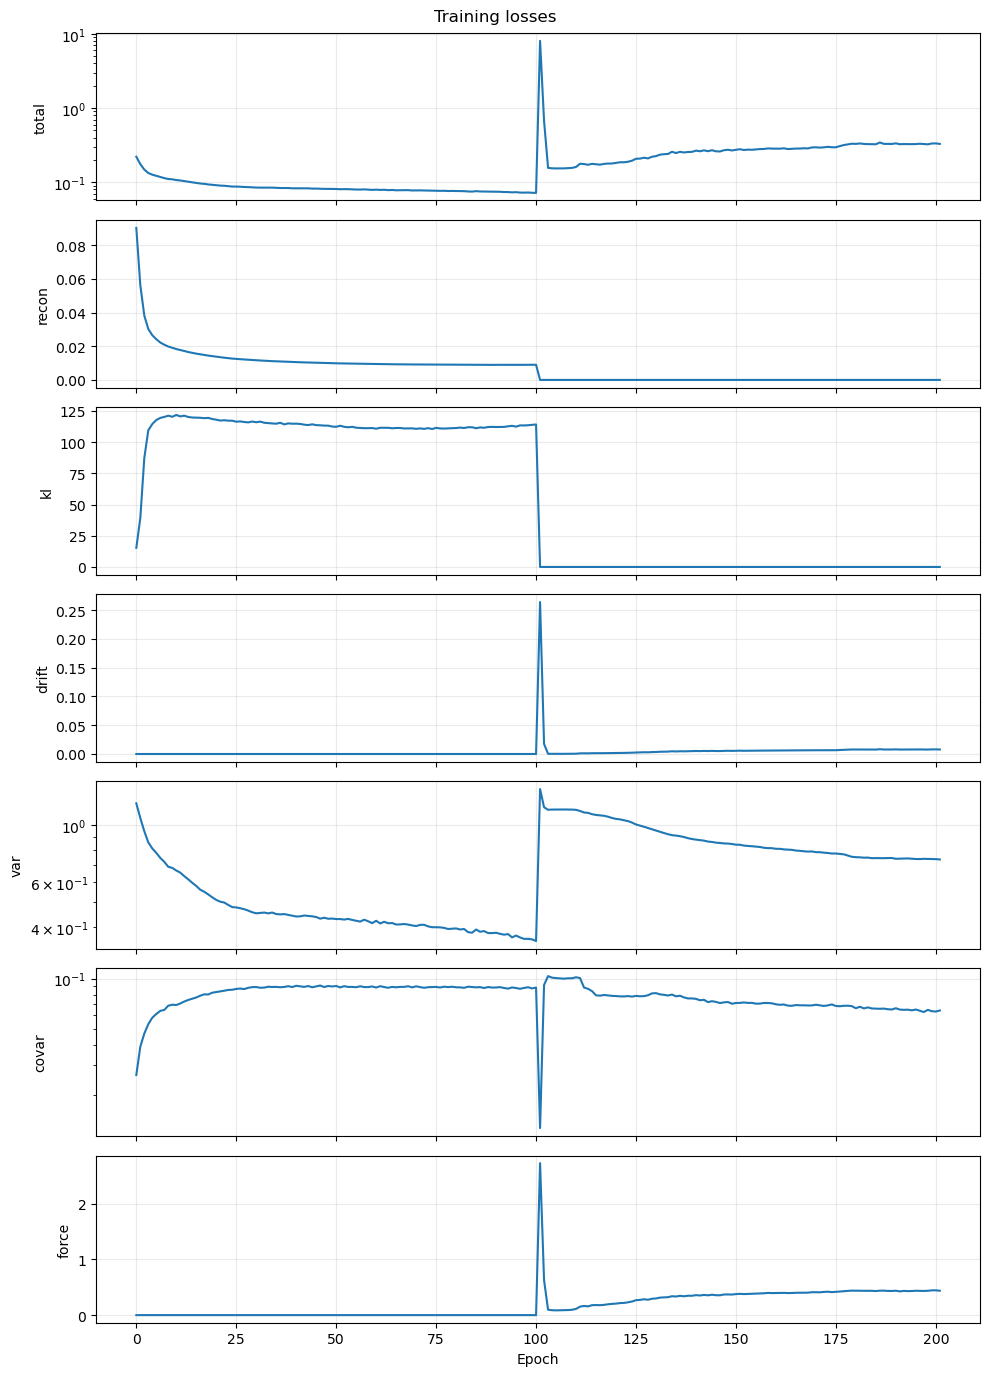

In [16]:
history = {
    "total": losses, "recon": recon_losses, "kl": kl_losses,
    "drift": drift_losses, "var": var_losses,
    "covar": covar_losses, "force": average_V,
}
fig, axes = plot_loss_history(history)
plt.show()


In [ ]:
# One reusable post-training call: it collects real encoder means and
# conditional generated latents/images, then computes latent SWD/FID and class metrics.
post_eval = evaluate_latent_model(
    f_trained,
    test_loader,
    device=device,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


In [ ]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


In [ ]:
projection_figures = plot_real_generated_projections(
    real_latents,
    generated_latents,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()
